COMPLETE EXPLORATORY DATA ANALYSIS - CREDIT RISK ASSESSMENT

📂 Loading cleaned data...
✅ Loaded: 149,391 rows, 11 columns

SECTION 1: TARGET VARIABLE ANALYSIS

📊 Target Distribution:
   0 = Good Credit (No Default):  139,382 (93.30%)
   1 = Bad Credit (Default):    10,009 (6.70%)
   📈 Overall Default Rate: 6.70%


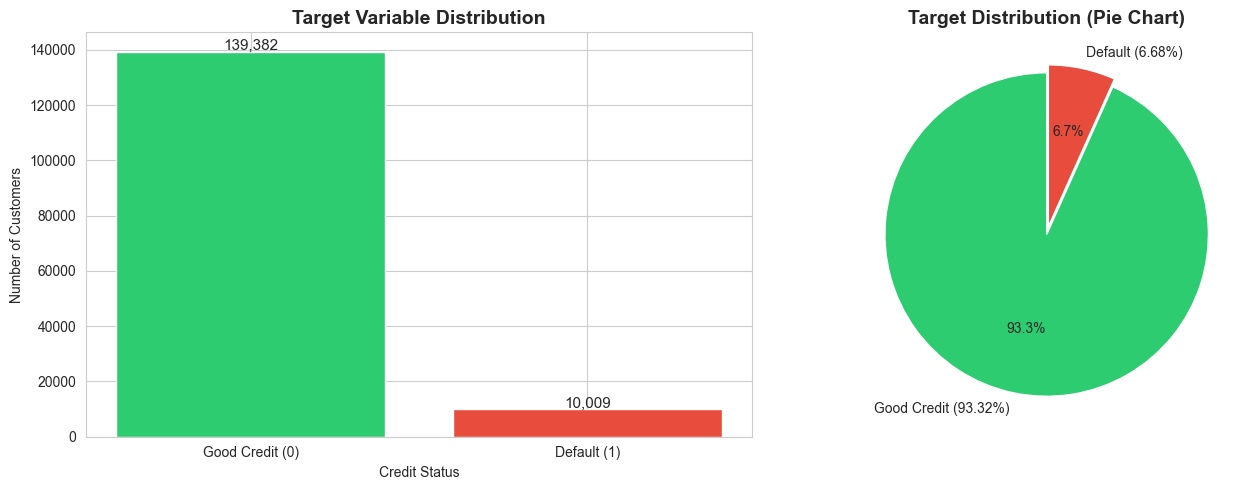


SECTION 2: NUMERICAL FEATURES DISTRIBUTION


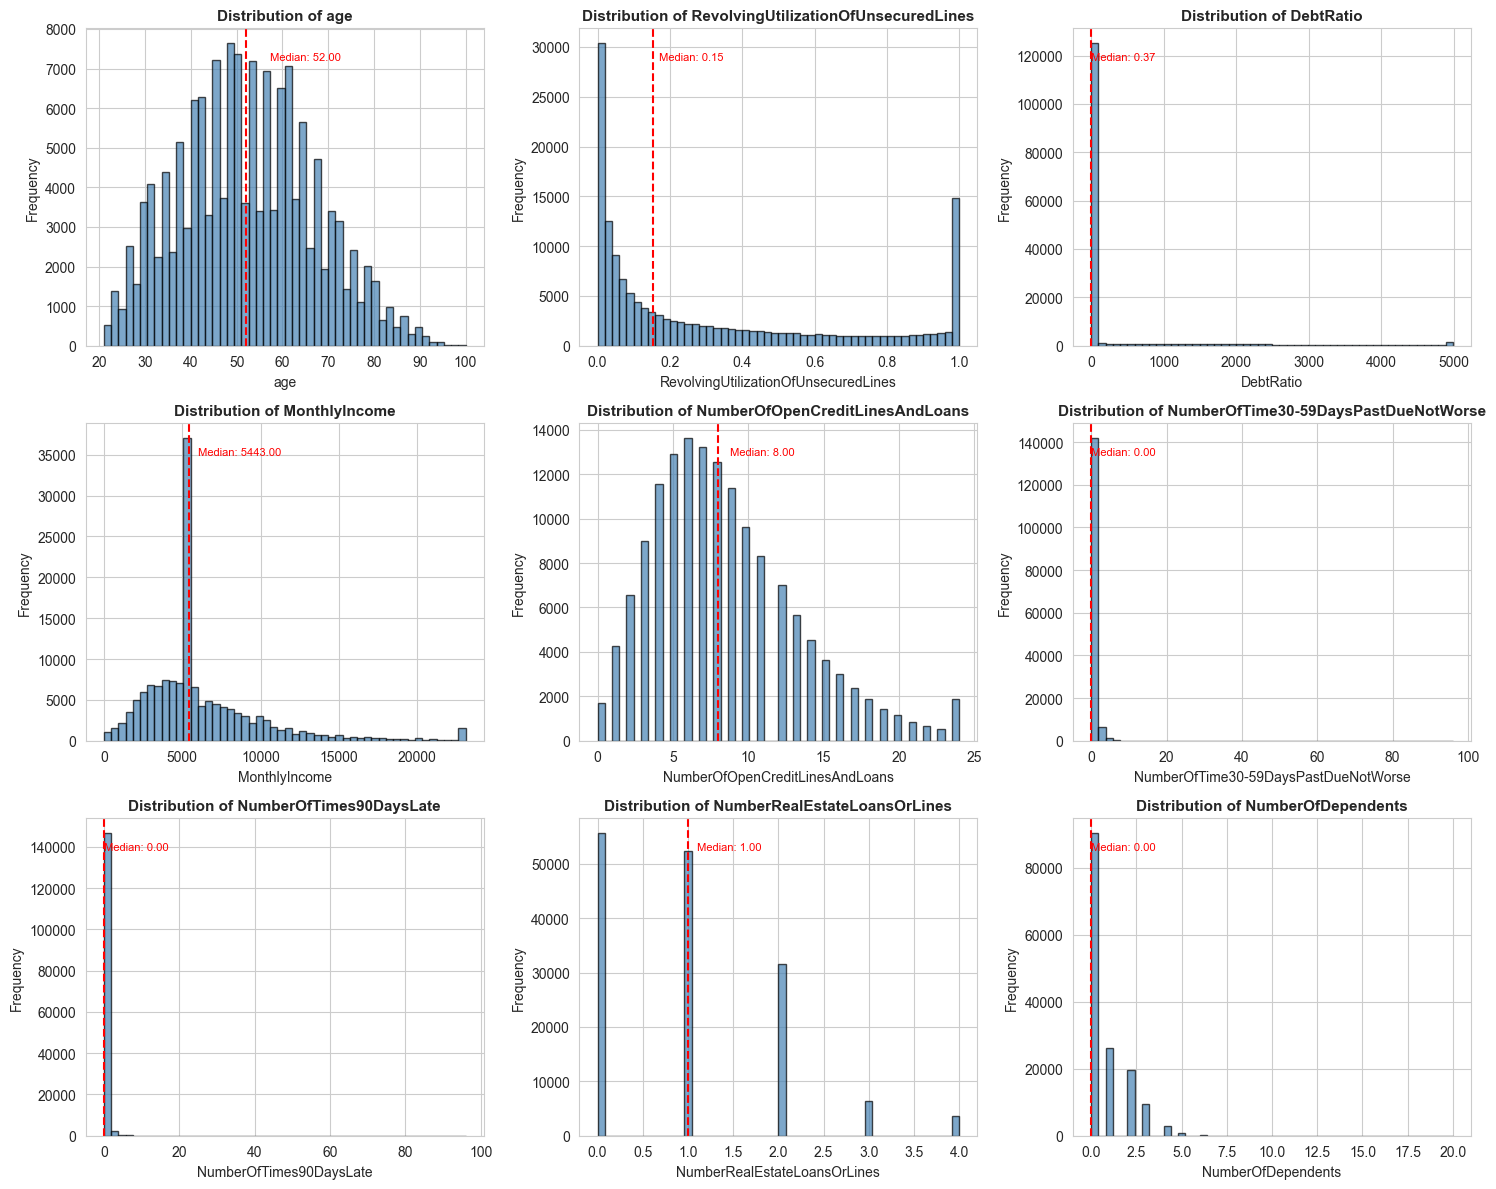


SECTION 3: BOXPLOTS (After Cleaning)


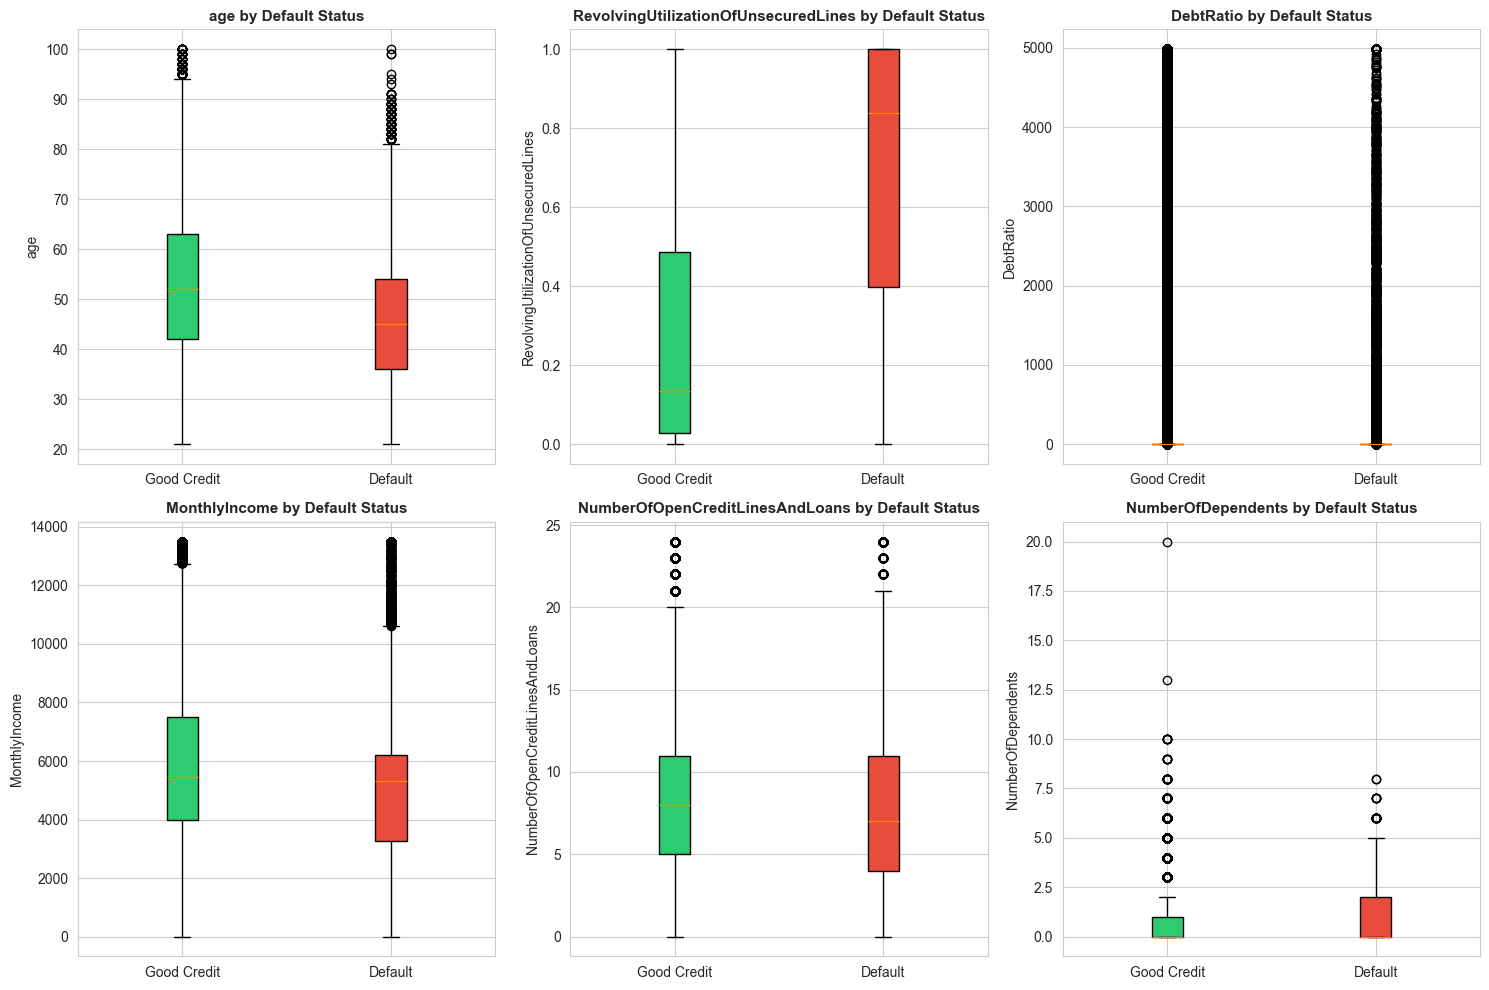


SECTION 4: CORRELATION ANALYSIS

📌 Feature Correlations with Default Risk:
--------------------------------------------------
   🔴 SeriousDlqin2yrs                              +1.0000
   🔴 RevolvingUtilizationOfUnsecuredLines          +0.2793
   🔴 NumberOfTime30-59DaysPastDueNotWorse          +0.2233
   🔴 NumberOfTimes90DaysLate                       +0.2183
   🔴 NumberOfTime60-89DaysPastDueNotWorse          +0.1505
   🟢 NumberOfDependents                            +0.0465
   🟢 DebtRatio                                     -0.0177
   🟢 MonthlyIncome                                 -0.0178
   🟢 NumberRealEstateLoansOrLines                  -0.0205
   🟢 NumberOfOpenCreditLinesAndLoans               -0.0324
   🟢 age                                           -0.1157


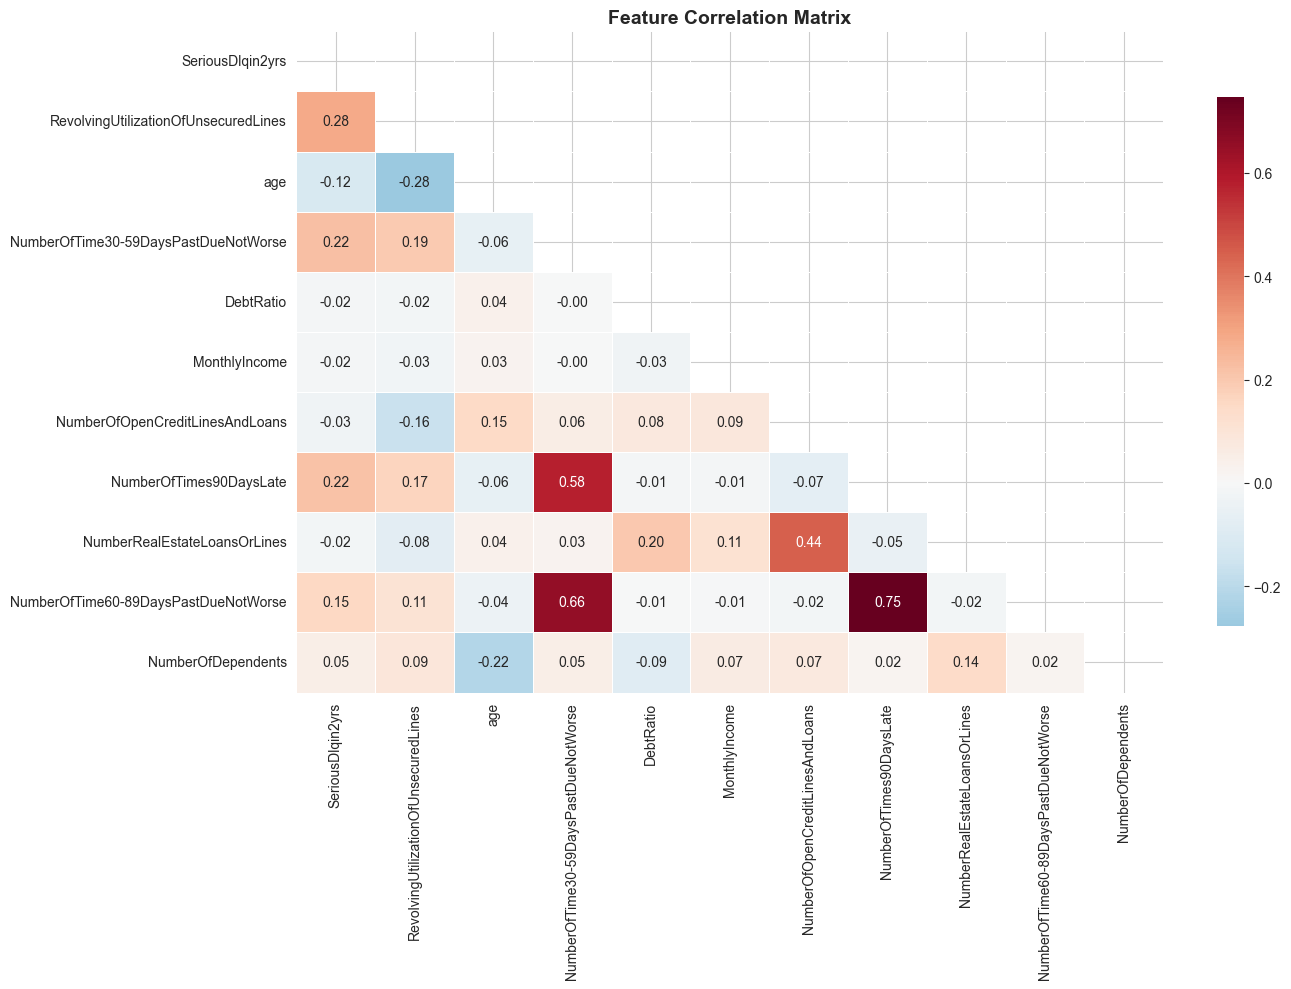


SECTION 5: AGE ANALYSIS

📊 Age Statistics:
   Min: 21
   Max: 100
   Mean: 52.3
   Median: 52.0


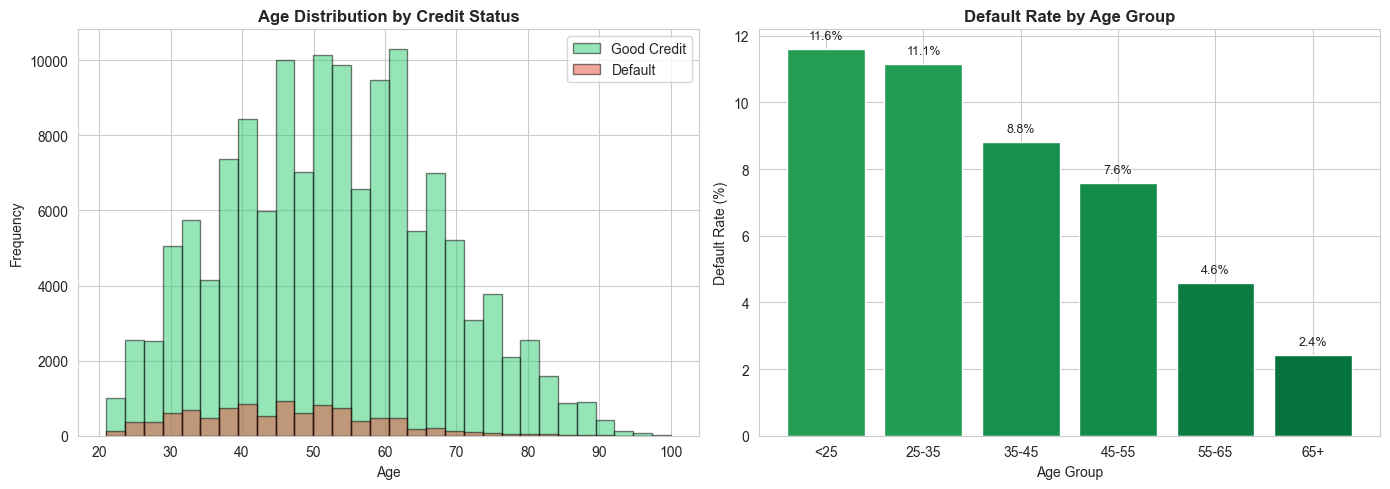


SECTION 6: CREDIT UTILIZATION ANALYSIS

📊 Credit Utilization Statistics:
   Min: 0.0000
   Max: 1.0000
   Mean: 0.3185
   Median: 0.1542


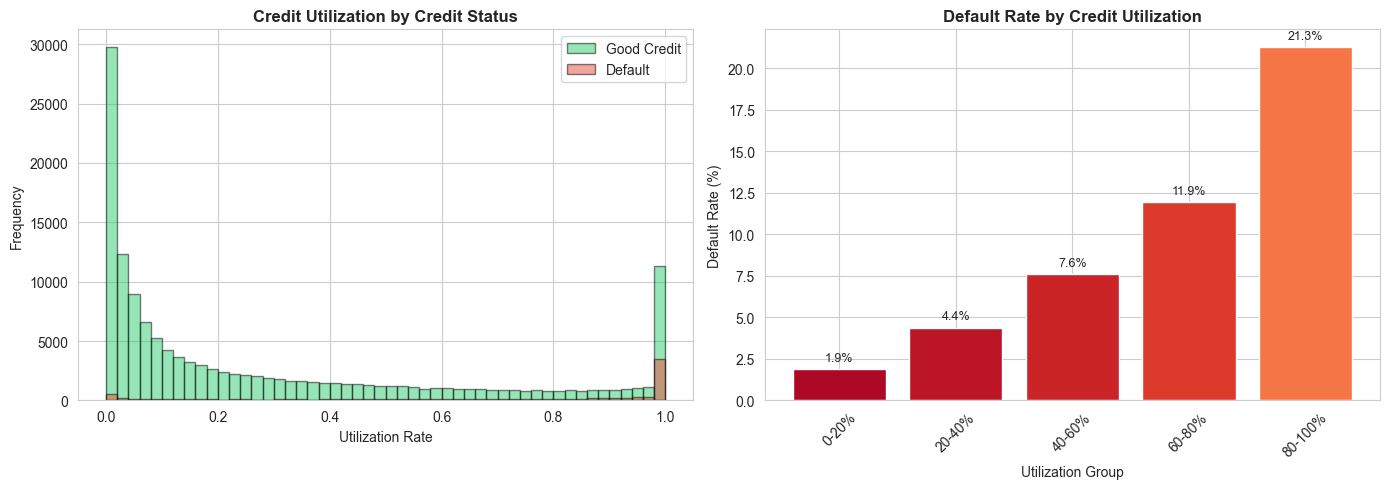


SECTION 7: INCOME ANALYSIS

📊 Monthly Income Statistics:
   Min: $1
   Max: $3,008,750
   Mean: $6,493
   Median: $5,443


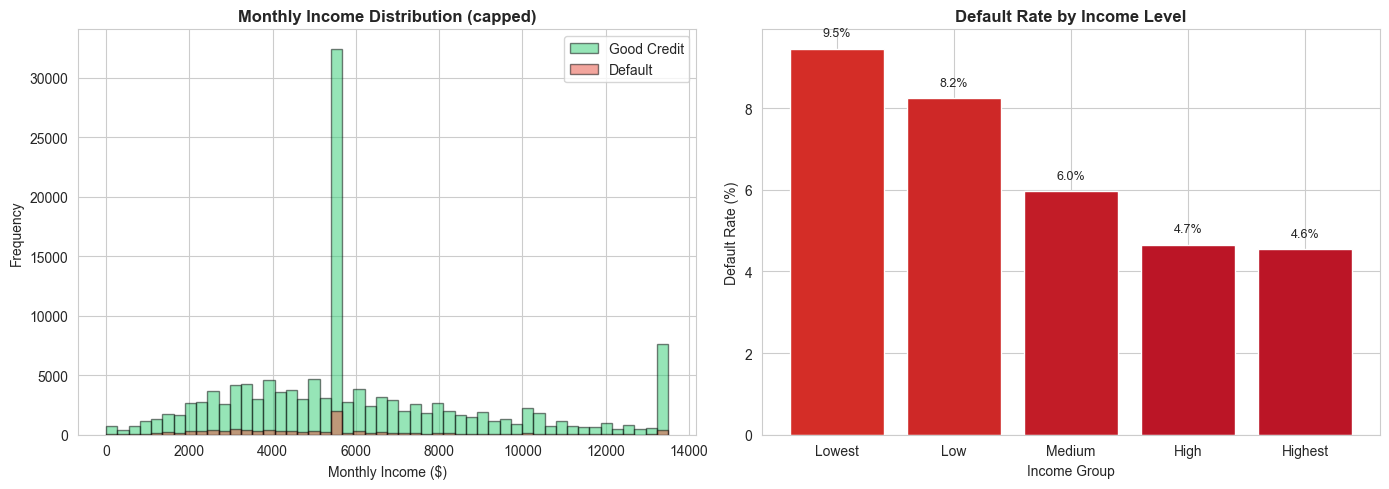


SECTION 8: DELINQUENCY HISTORY ANALYSIS
   30-59 Days: 23,718 customers, Default rate: 20.4%
   60-89 Days: 7,340 customers, Default rate: 35.8%
   90+ Days: 8,063 customers, Default rate: 41.3%
   Any Delinquency: 30,088 customers, Default rate: 22.0%


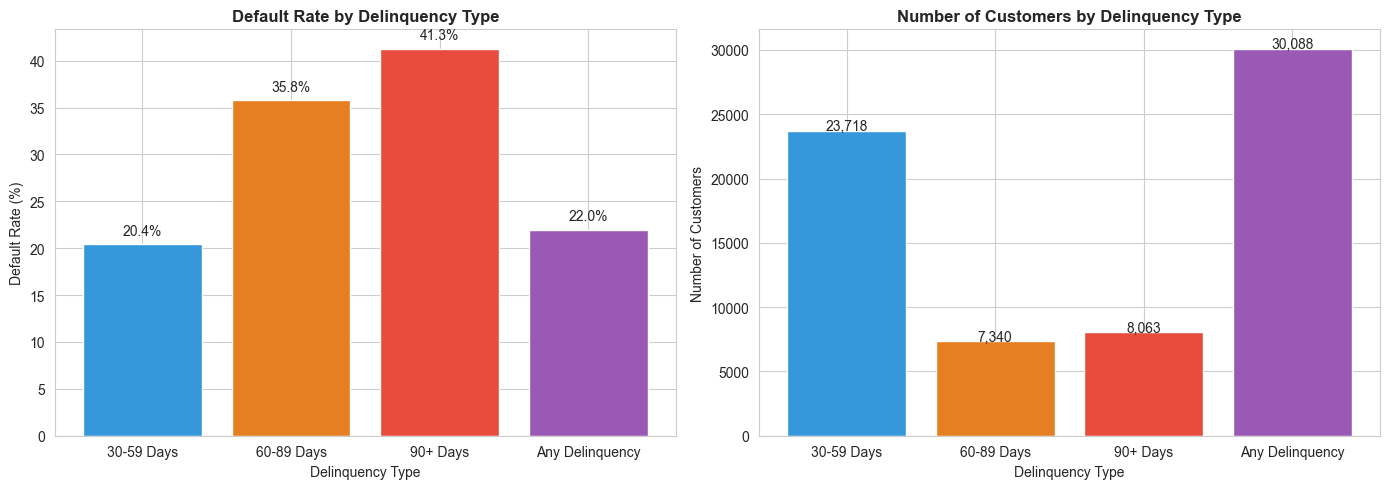


SECTION 9: DEBT RATIO ANALYSIS

📊 Debt Ratio Statistics:
   Min: 0.0000
   Max: 4985.1000
   Mean: 317.8927
   Median: 0.3682


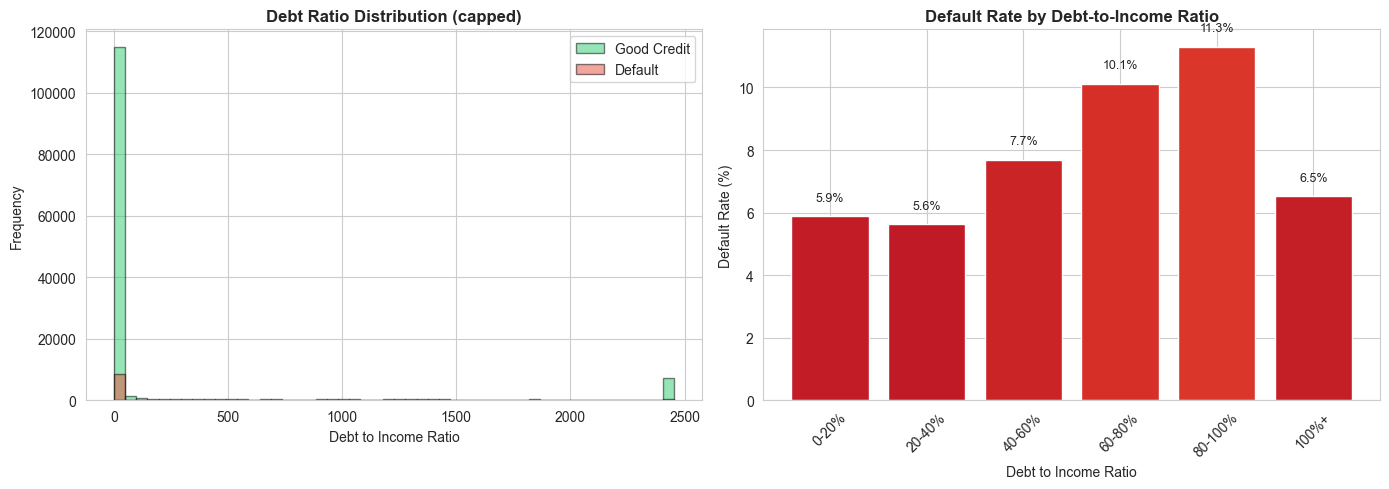


SECTION 10: DEPENDENTS ANALYSIS

📊 Dependents Statistics:
   Min: 0.0
   Max: 20.0
   Mean: 0.74
   Median: 0


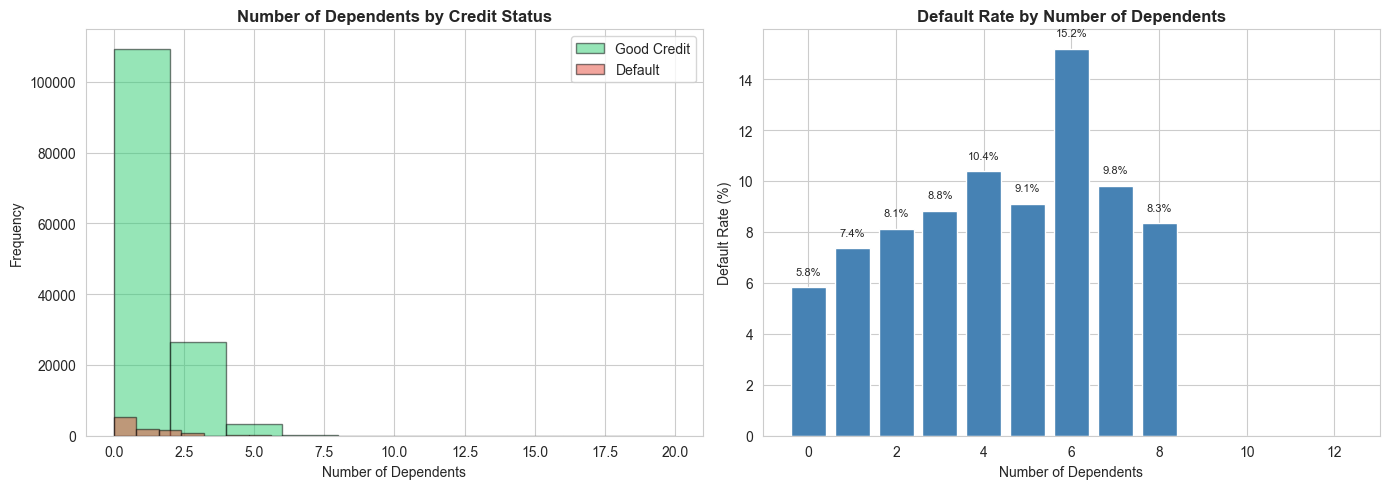


FINAL EDA SUMMARY REPORT

╔══════════════════════════════════════════════════════════════════════════════╗
║                         CREDIT RISK EDA COMPLETE                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   ├── Total Records: 149,391
   ├── Total Features: 19
   ├── Default Rate: 6.70%
   └── Good Credit Rate: 93.30%

📈 KEY FINDINGS:

   1. AGE:
      ├── Younger customers (<35) have significantly higher default rates
      ├── Default rate peaks at 11.6% for age group <25
      └── Best credit performance: 65+ age group (2.4%)

   2. CREDIT UTILIZATION:
      ├── Strongest predictor of default
      ├── Customers with >80% utilization have 21.3% default rate
      └── Customers with <20% utilization have 1.9% default rate

   3. DELINQUENCY HISTORY:
      ├── Any past delinquency increases default risk significantly
      ├── 90+ day delinquency: 41.3% default rate
      └── Customers with clean his

In [2]:
"""
COMPLETE CREDIT RISK EDA - ALL VISUALIZATIONS (FIXED)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("COMPLETE EXPLORATORY DATA ANALYSIS - CREDIT RISK ASSESSMENT")
print("=" * 80)

# Load cleaned data
print("\n📂 Loading cleaned data...")
df = pd.read_csv('C:/Users/AlexB/Desktop/credit_risk_assessment/data/processed/credit_data_cleaned.csv')
print(f"✅ Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Create reports folder
import os
os.makedirs('C:/Users/AlexB/Desktop/credit_risk_assessment/reports', exist_ok=True)

# ============================================================================
# SECTION 1: TARGET VARIABLE ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 1: TARGET VARIABLE ANALYSIS")
print("=" * 80)

# 1.1 Target Distribution
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_percent = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print(f"\n📊 Target Distribution:")
print(f"   0 = Good Credit (No Default):  {target_counts[0]:,} ({target_percent[0]:.2f}%)")
print(f"   1 = Bad Credit (Default):    {target_counts[1]:,} ({target_percent[1]:.2f}%)")
print(f"   📈 Overall Default Rate: {df['SeriousDlqin2yrs'].mean():.2%}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Good Credit (0)', 'Default (1)'], target_counts.values, color=colors)
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Credit Status')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
                 f'{val:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_counts.values, labels=['Good Credit (93.32%)', 'Default (6.68%)'], 
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title('Target Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/01_target_distribution.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 2: NUMERICAL FEATURES DISTRIBUTION
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 2: NUMERICAL FEATURES DISTRIBUTION")
print("=" * 80)

# Select numerical columns
num_cols = ['age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 
            'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 
            'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
            'NumberRealEstateLoansOrLines', 'NumberOfDependents']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # For income, cap at 99th percentile for better visualization
    if col == 'MonthlyIncome':
        plot_data = df[col].clip(upper=df[col].quantile(0.99))
    else:
        plot_data = df[col]
    
    axes[i].hist(plot_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    # Add median line
    median_val = df[col].median()
    axes[i].axvline(median_val, color='red', linestyle='--', linewidth=1.5)
    axes[i].text(median_val * 1.1, axes[i].get_ylim()[1] * 0.9, f'Median: {median_val:.2f}', 
                 fontsize=8, color='red')

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/02_numerical_distributions.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 3: BOXPLOTS FOR OUTLIER DETECTION
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 3: BOXPLOTS (After Cleaning)")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

boxplot_cols = ['age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 
                'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']

for i, col in enumerate(boxplot_cols):
    if col == 'MonthlyIncome':
        plot_data = df[col].clip(upper=df[col].quantile(0.95))
    else:
        plot_data = df[col]
    
    # Create boxplot by target
    data_to_plot = [plot_data[df['SeriousDlqin2yrs'] == 0], 
                    plot_data[df['SeriousDlqin2yrs'] == 1]]
    
    bp = axes[i].boxplot(data_to_plot, labels=['Good Credit', 'Default'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[i].set_title(f'{col} by Default Status', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/03_boxplots.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 4: CORRELATION ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 4: CORRELATION ANALYSIS")
print("=" * 80)

# Correlation with target
correlations = df.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)
print("\n📌 Feature Correlations with Default Risk:")
print("-" * 50)
for feature, corr in correlations.items():
    indicator = "🔴" if corr > 0.1 else "🟡" if corr > 0.05 else "🟢"
    print(f"   {indicator} {feature:45} {corr:+.4f}")

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/04_correlation_heatmap.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 5: AGE ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 5: AGE ANALYSIS")
print("=" * 80)

# Age statistics
print(f"\n📊 Age Statistics:")
print(f"   Min: {df['age'].min()}")
print(f"   Max: {df['age'].max()}")
print(f"   Mean: {df['age'].mean():.1f}")
print(f"   Median: {df['age'].median():.1f}")

# Create age groups
df['AgeGroup'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100],
                         labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])

age_default = df.groupby('AgeGroup')['SeriousDlqin2yrs'].mean() * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by default status
for status, color, label in [(0, '#2ecc71', 'Good Credit'), (1, '#e74c3c', 'Default')]:
    axes[0].hist(df[df['SeriousDlqin2yrs'] == status]['age'], bins=30, alpha=0.5, 
                 color=color, label=label, edgecolor='black')
axes[0].set_title('Age Distribution by Credit Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Default rate by age group
colors = plt.cm.RdYlGn_r(age_default.values / 100)
bars = axes[1].bar(range(len(age_default)), age_default.values, color=colors)
axes[1].set_title('Default Rate by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks(range(len(age_default)))
axes[1].set_xticklabels(age_default.index)

for bar, val in zip(bars, age_default.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/05_age_analysis.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 6: CREDIT UTILIZATION ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 6: CREDIT UTILIZATION ANALYSIS")
print("=" * 80)

# Utilization statistics
print(f"\n📊 Credit Utilization Statistics:")
print(f"   Min: {df['RevolvingUtilizationOfUnsecuredLines'].min():.4f}")
print(f"   Max: {df['RevolvingUtilizationOfUnsecuredLines'].max():.4f}")
print(f"   Mean: {df['RevolvingUtilizationOfUnsecuredLines'].mean():.4f}")
print(f"   Median: {df['RevolvingUtilizationOfUnsecuredLines'].median():.4f}")

# Create utilization groups
df['UtilGroup'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], 
                          bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                          labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])

util_default = df.groupby('UtilGroup')['SeriousDlqin2yrs'].mean() * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Utilization distribution by default status
for status, color, label in [(0, '#2ecc71', 'Good Credit'), (1, '#e74c3c', 'Default')]:
    data = df[df['SeriousDlqin2yrs'] == status]['RevolvingUtilizationOfUnsecuredLines']
    axes[0].hist(data, bins=50, alpha=0.5, color=color, label=label, edgecolor='black')
axes[0].set_title('Credit Utilization by Credit Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Default rate by utilization group
colors = plt.cm.RdYlGn_r(1 - util_default.values / 100)
bars = axes[1].bar(range(len(util_default)), util_default.values, color=colors)
axes[1].set_title('Default Rate by Credit Utilization', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Utilization Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks(range(len(util_default)))
axes[1].set_xticklabels(util_default.index, rotation=45)

for bar, val in zip(bars, util_default.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/06_utilization_analysis.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 7: INCOME ANALYSIS (FIXED)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 7: INCOME ANALYSIS")
print("=" * 80)

# Income statistics
print(f"\n📊 Monthly Income Statistics:")
print(f"   Min: ${df['MonthlyIncome'].min():,.0f}")
print(f"   Max: ${df['MonthlyIncome'].max():,.0f}")
print(f"   Mean: ${df['MonthlyIncome'].mean():,.0f}")
print(f"   Median: ${df['MonthlyIncome'].median():,.0f}")

# Create income groups using quantiles with duplicates handled
try:
    df['IncomeGroup'] = pd.qcut(df['MonthlyIncome'], q=5, 
                                  labels=['Lowest', 'Low', 'Medium', 'High', 'Highest'],
                                  duplicates='drop')
except ValueError:
    # If qcut fails, use custom bins
    income_bins = [0, 3000, 5000, 8000, 12000, float('inf')]
    income_labels = ['Lowest', 'Low', 'Medium', 'High', 'Highest']
    df['IncomeGroup'] = pd.cut(df['MonthlyIncome'], bins=income_bins, labels=income_labels)

income_default = df.groupby('IncomeGroup')['SeriousDlqin2yrs'].mean() * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income distribution by default status (capped)
income_capped = df['MonthlyIncome'].clip(upper=df['MonthlyIncome'].quantile(0.95))
for status, color, label in [(0, '#2ecc71', 'Good Credit'), (1, '#e74c3c', 'Default')]:
    data = income_capped[df['SeriousDlqin2yrs'] == status]
    axes[0].hist(data, bins=50, alpha=0.5, color=color, label=label, edgecolor='black')
axes[0].set_title('Monthly Income Distribution (capped)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monthly Income ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Default rate by income group
colors = plt.cm.RdYlGn_r(1 - income_default.values / 100)
bars = axes[1].bar(range(len(income_default)), income_default.values, color=colors)
axes[1].set_title('Default Rate by Income Level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Income Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks(range(len(income_default)))
axes[1].set_xticklabels(income_default.index)

for bar, val in zip(bars, income_default.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/07_income_analysis.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 8: DELINQUENCY HISTORY ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 8: DELINQUENCY HISTORY ANALYSIS")
print("=" * 80)

# Create delinquency indicators
df['Has30DayDelinquency'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] > 0).astype(int)
df['Has60DayDelinquency'] = (df['NumberOfTime60-89DaysPastDueNotWorse'] > 0).astype(int)
df['Has90DayDelinquency'] = (df['NumberOfTimes90DaysLate'] > 0).astype(int)
df['AnyDelinquency'] = (df[['Has30DayDelinquency', 'Has60DayDelinquency', 'Has90DayDelinquency']].sum(axis=1) > 0).astype(int)

# Calculate default rates
delinquency_types = ['30-59 Days', '60-89 Days', '90+ Days', 'Any Delinquency']
delinquency_cols = ['Has30DayDelinquency', 'Has60DayDelinquency', 'Has90DayDelinquency', 'AnyDelinquency']
default_rates = []
counts = []

for col in delinquency_cols:
    rate = df[df[col] == 1]['SeriousDlqin2yrs'].mean() * 100
    cnt = df[col].sum()
    default_rates.append(rate)
    counts.append(cnt)
    print(f"   {delinquency_types[len(default_rates)-1]}: {cnt:,} customers, Default rate: {rate:.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by delinquency type
colors = ['#3498db', '#e67e22', '#e74c3c', '#9b59b6']
bars = axes[0].bar(delinquency_types, default_rates, color=colors)
axes[0].set_title('Default Rate by Delinquency Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Delinquency Type')
axes[0].set_ylabel('Default Rate (%)')
for bar, val in zip(bars, default_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val:.1f}%', ha='center', fontsize=10)

# Number of customers by delinquency type
bars2 = axes[1].bar(delinquency_types, counts, color=colors)
axes[1].set_title('Number of Customers by Delinquency Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Delinquency Type')
axes[1].set_ylabel('Number of Customers')
for bar, val in zip(bars2, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/08_delinquency_analysis.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 9: DEBT RATIO ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 9: DEBT RATIO ANALYSIS")
print("=" * 80)

# Debt ratio statistics
print(f"\n📊 Debt Ratio Statistics:")
print(f"   Min: {df['DebtRatio'].min():.4f}")
print(f"   Max: {df['DebtRatio'].max():.4f}")
print(f"   Mean: {df['DebtRatio'].mean():.4f}")
print(f"   Median: {df['DebtRatio'].median():.4f}")

# Create debt ratio groups
df['DebtGroup'] = pd.cut(df['DebtRatio'], 
                          bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0, float('inf')],
                          labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '100%+'])

debt_default = df.groupby('DebtGroup')['SeriousDlqin2yrs'].mean() * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Debt ratio distribution
debt_capped = df['DebtRatio'].clip(upper=df['DebtRatio'].quantile(0.95))
for status, color, label in [(0, '#2ecc71', 'Good Credit'), (1, '#e74c3c', 'Default')]:
    data = debt_capped[df['SeriousDlqin2yrs'] == status]
    axes[0].hist(data, bins=50, alpha=0.5, color=color, label=label, edgecolor='black')
axes[0].set_title('Debt Ratio Distribution (capped)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Debt to Income Ratio')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Default rate by debt group
colors = plt.cm.RdYlGn_r(1 - debt_default.values / 100)
bars = axes[1].bar(range(len(debt_default)), debt_default.values, color=colors)
axes[1].set_title('Default Rate by Debt-to-Income Ratio', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Debt to Income Ratio')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks(range(len(debt_default)))
axes[1].set_xticklabels(debt_default.index, rotation=45)

for bar, val in zip(bars, debt_default.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/09_debt_ratio_analysis.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 10: DEPENDENTS ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 10: DEPENDENTS ANALYSIS")
print("=" * 80)

# Dependents statistics
print(f"\n📊 Dependents Statistics:")
print(f"   Min: {df['NumberOfDependents'].min()}")
print(f"   Max: {df['NumberOfDependents'].max()}")
print(f"   Mean: {df['NumberOfDependents'].mean():.2f}")
print(f"   Median: {df['NumberOfDependents'].median():.0f}")

# Default rate by number of dependents
dependents_default = df.groupby('NumberOfDependents')['SeriousDlqin2yrs'].mean() * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dependents distribution
for status, color, label in [(0, '#2ecc71', 'Good Credit'), (1, '#e74c3c', 'Default')]:
    axes[0].hist(df[df['SeriousDlqin2yrs'] == status]['NumberOfDependents'], 
                 bins=10, alpha=0.5, color=color, label=label, edgecolor='black')
axes[0].set_title('Number of Dependents by Credit Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Dependents')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Default rate by dependents
bars = axes[1].bar(range(len(dependents_default)), dependents_default.values, color='steelblue')
axes[1].set_title('Default Rate by Number of Dependents', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Dependents')
axes[1].set_ylabel('Default Rate (%)')

for bar, val in zip(bars, dependents_default.values):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                     f'{val:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('C:/Users/AlexB/Desktop/credit_risk_assessment/reports/10_dependents_analysis.png', dpi=150)
plt.show()

# ============================================================================
# SECTION 11: FINAL SUMMARY REPORT
# ============================================================================

print("\n" + "=" * 80)
print("FINAL EDA SUMMARY REPORT")
print("=" * 80)

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                         CREDIT RISK EDA COMPLETE                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   ├── Total Records: {len(df):,}
   ├── Total Features: {len(df.columns)}
   ├── Default Rate: {df['SeriousDlqin2yrs'].mean():.2%}
   └── Good Credit Rate: {(1 - df['SeriousDlqin2yrs'].mean()):.2%}

📈 KEY FINDINGS:

   1. AGE:
      ├── Younger customers (<35) have significantly higher default rates
      ├── Default rate peaks at {age_default.max():.1f}% for age group {age_default.idxmax()}
      └── Best credit performance: {age_default.idxmin()} age group ({age_default.min():.1f}%)

   2. CREDIT UTILIZATION:
      ├── Strongest predictor of default
      ├── Customers with >80% utilization have {util_default.iloc[-1]:.1f}% default rate
      └── Customers with <20% utilization have {util_default.iloc[0]:.1f}% default rate

   3. DELINQUENCY HISTORY:
      ├── Any past delinquency increases default risk significantly
      ├── 90+ day delinquency: {default_rates[2]:.1f}% default rate
      └── Customers with clean history: {100 - default_rates[3]:.1f}% lower risk

   4. INCOME:
      ├── Lower income = higher default risk
      ├── Lowest income group: {income_default.iloc[0]:.1f}% default rate
      └── Highest income group: {income_default.iloc[-1]:.1f}% default rate

   5. DEBT RATIO:
      ├── Higher debt-to-income ratio increases risk
      └── Debt ratio >100%: {debt_default.iloc[-1]:.1f}% default rate

📁 OUTPUT FILES (saved to reports folder):
   ├── 01_target_distribution.png
   ├── 02_numerical_distributions.png
   ├── 03_boxplots.png
   ├── 04_correlation_heatmap.png
   ├── 05_age_analysis.png
   ├── 06_utilization_analysis.png
   ├── 07_income_analysis.png
   ├── 08_delinquency_analysis.png
   ├── 09_debt_ratio_analysis.png
   └── 10_dependents_analysis.png

✅ EDA COMPLETE! Ready for Feature Engineering and Modeling.
""")

print("=" * 80)
print("EDA COMPLETE! All charts saved to reports folder.")
print("=" * 80)